# Bee Smart
 The objective of this project is to make a predictive model using AI about a bee behavoir during the day to detect anomalies and therefore know what's the cause in a pursuit to preserve this animals. 

 The idea for the data is classify them in 4 categories
1. BTE (by the entry) - short intervals of time, from 1 sec up to 3 min in where the bee is in the entrance (_piquera_) or over the reader (max of 30 min).
2. SM (short mission)- short activity between 3 - 6 min.
3. FG (foraging) - forage and exploration activity, from 6 minutes up to 6 hours. 
4. DB (departed bee) - last detection of every bee during its life

The data is in two main sets, one already labeled and the other one in raw

It's also important to consider that the Hive 1 is our control group and the Hive 2 is the infected Hive

In the classification we consider to acitvity hours categories: 
1. Sunrise (7am - 12pm)
2. Sunset (12pm- 7pm)


 
    *Papers about similar projects in the past can be found at the end of this notebook.*



## 1. Raw data exploration and filtering
First we download the csv and filter the data, we have already a labeled archive but we're going to try to labeled by our own and compare results later. 


In [1]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler


In [2]:
import pandas as pd
import numpy as np

# Set the path for files
general_path = '/Users/ralo/Library/CloudStorage/OneDrive-UNIVERSIDADNACIONALAUTÓNOMADEMÉXICO/TECNOLOGÍA/' # General path for data files
filtered_data_path = 'Semestre 7/BeeSmart/data/filtered_data_sensors.csv'
raw_copy_MH1_path = 'Semestre 7/BeeSmart/data/raw_copy_MH1Exploration.xlsx'
raw_copy_MH2_path = 'Semestre 7/BeeSmart/data/raw_copy_MH2Exploration.xlsx'

# load them as datasets
df_filtered = pd.read_csv(general_path + filtered_data_path)
#df_raw_MH1 = pd.read_excel(general_path + raw_copy_MH1_path, sheet_name=None) 
""" We add the sheetname=none to add all the sheets of our excel document, its important to notice that this creates a dictionary of dataframes not a single
dataframe, therefore if we want to acces to every sheet we use the key, or the index or the sheet name"""
#df_raw_MH2 = pd.read_excel(general_path + raw_copy_MH2_path, sheet_name=None)

#print(type(df_raw_MH1))
#print(type(df_raw_MH2))

' We add the sheetname=none to add all the sheets of our excel document, its important to notice that this creates a dictionary of dataframes not a single\ndataframe, therefore if we want to acces to every sheet we use the key, or the index or the sheet name'

Watching the column names for our filtered dataset

As we mentioned before, this dataset is already filtered and labeled so no further filtering is required

In [ ]:
df_filtered.head()

Watching the name of our sheets in the raw data

In [ ]:
print(df_raw_MH1.keys())
print(df_raw_MH2.keys())

In [ ]:
print(len(df_raw_MH2))

With a manual check we saw that for raw MH1 we have one excel sheet for every day, but not all days have data, with that knowledge lets delete them, we're also going to delete the "Hoja 2" sheet from the MH2

In [ ]:
# Converting keys to a list to acces them by index
sheet_names = list(df_raw_MH1.keys())
sheet_names2 = list(df_raw_MH2.keys())

# Indexes to drop (days without data) (July 1, 4, 5, 6, 7)
drop_MH1 = [0, 3, 4, 5, 6]

# Drop 
for idx in sorted(drop_MH1, reverse=True): 
    sheet = sheet_names[idx]
    df_raw_MH1.pop(sheet, None)

print(df_raw_MH1.keys())



In [ ]:
# Indexes to drop (Hoja 2)
drop_MH2 = [36, 37]

# Poping the key 35 "Hoja 2"
for idx in drop_MH2:
    key = sheet_names2[idx]
    df_raw_MH2.pop(key, None)

print(df_raw_MH2.keys())

In [ ]:
print(type(df_raw_MH1))
print(type(df_raw_MH2))

Now that we've filtered all the days without data we can concat all other sheets to create a unique dataframe, also we add a first column, day, to identify flights per day way more easily.
We also concat with the Hive 2, the "df_raw_MH2" that is our infected hive.

In [ ]:
def flatten_excel_dict(df_dict):
    dfs = []
    for i, (sheet_name, df) in enumerate(df_dict.items(), start=1):
        if df is not None and not df.empty:
            df = df.copy()
            df["DAY"] = i
            df["SHEET"] = sheet_name  # optional but useful
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


# Concating both DF
df_MH1 = flatten_excel_dict(df_raw_MH1)
df_MH2 = flatten_excel_dict(df_raw_MH2)

df_MH1["HIVE"] = "Control"
df_MH2["HIVE"] = "Infected"
df_final = pd.concat([df_MH1, df_MH2], ignore_index=True)

df_final.head()



The first 5 columns of our dataset are useless in this project, as the IDs they represent are not useful at al here. Therefore we can delete them to only have the parameters we care about.

Also we're deleting row where colmena = "F" & ID = "FFF", this are just very few rows, so this decisition will not have any serious impact in the training of the model

In [ ]:
# Droping columns from index 0 to 5
df_final = df_final.drop(df_final.iloc[:, 0:6], axis = 1) # As we are deleting by index, be aware of not rerun this cell more than once, as it will delete columns we don't want to be deleted
# Looking the new df with this columns deleted
df_final.head(15)


In [ ]:
# Droping rows (4-6, 9-11), the ones that have FFF
df_final = df_final.drop(df_final.index[list(range(4,7)) + list(range(9,12))])
df_final.head(10)



In [ ]:
df_final.shape 

We now are also dropping the columns Colmena, as we already labeled the control and infected hives, and its easier to work with that names, as well as Horam, Horadecimal, hora MX, Hora Negativo, Hora_entero, Minutos, Segundos as we can work only with Tiempo and make a conversation for what we need.

In [ ]:
print(df_final.columns.tolist())


In [ ]:
df_final = df_final.drop(['Colmena', 'Horam', 'HoraS', 'Horadecimal', 'Hora MX(-5)', 'Hora_negativo', 
                              'Hora_entero', 'Minutos', 'Segundos', 'Duracion (hr)', 'Duracion(min)', 'SHEET', 
                              'Unnamed: 0', 'Unnamed: 17'], axis = 1)
df_final.head()

Finally, we're going to do a difference of (time - 5000) to match mexican hour, we dont care about post midnight flights (00:00:00) as they are not part of our final labelling proceess

In [ ]:
df_final["Tiempo"] -= 50000 

df_final.head()

We'll end here for this data set, the other one follows the same steps, but we're wotking on that one later

# 2. Labeling the raw data

Now that the data has been filtered we're going to work with them trying to classify each bee flight in to 4 categories explained at the begining. 

1. BTE (by the entry) - short intervals of time, from 1 sec up to 3 min in where the bee is in the entrance (_piquera_) or over the reader (max of 30 min).
2. SM (short mission)- short activity between 3 - 6 min.
3. FG (foraging) - forage and exploration activity, from 6 minutes up to 6 hours. 
4. DB (departed bee) - last detection of every bee during its life


In the classification we consider to acitvity hours categories: 
1. Sunrise (7am - 12pm)
2. Sunset (12pm- 7pm)

First we're going to divide between sunrise and sunset, and deleting all registers that dont match any of these labels

In [ ]:
# Enumerate through each sheet, adding a Sunrise-Sunset Label
df_final["DayPeriod"] = np.where(
    (df_final["Tiempo"] >= 70000) & (df_final["Tiempo"] < 120000),
    "Sunrise",
    np.where(
        (df_final["Tiempo"] >= 120000) & (df_final["Tiempo"] < 190000), 
           "Sunset",
           np.nan
    )
)

df_final = df_final[
    ((df_final["Tiempo"] >= 70000) & (df_final["Tiempo"] < 120000)) |
    ((df_final["Tiempo"] >= 120000) & (df_final["Tiempo"] < 190000))
]


df_final.head()

In [ ]:
df_final.shape


Now were goin to do this classification and create a new dataframe with this  information following the next rules


1. BTE (by the entry) - short intervals of time, from 1 sec up to 3 min in where the bee is in the entrance (_piquera_) or over the reader (max of 30 min).
2. SM (short mission)- short activity between 3 - 6 min.
3. FG (foraging) - forage and exploration activity, from 6 minutes up to 6 hours. 
4. DB (departed bee) - last detection of every bee during its life



In [ ]:
# Function to convert hhmmss (int or str) → seconds
def hhmmss_to_seconds(x):
    x = int(x)
    hh = x // 10000
    mm = (x % 10000) // 100
    ss = x % 100
    return hh*3600 + mm*60 + ss

# Apply conversion
df_final["Tiempo_sec"] = df_final["Tiempo"].apply(hhmmss_to_seconds)

# Sort by ID, DAY, Tiempo
df_final = df_final.sort_values(by=["ID", "DAY", "Tiempo_sec"])

# Compute duration (seconds) per bee per day
df_final["Tiempo_diff"] = df_final.groupby(["ID", "DAY"])["Tiempo_sec"].diff()

missions = []

for bee_id, group in df_final.groupby(["ID", "DAY"]):
    group = group.sort_values("Tiempo").reset_index(drop=True)

    # Iterate in steps of 2 (departure-return pairs)
    for i in range(0, len(group), 2):
        if i + 1 < len(group):  # we have a return
            dep_time = group.loc[i, "Tiempo_sec"]
            ret_time = group.loc[i+1, "Tiempo_sec"]
            diff = ret_time - dep_time
            missions.append({
                "ID": bee_id[0],
                "DAY": bee_id[1],
                "Hive": group.loc[i, "HIVE"],
                "DayPeriod": group.loc[i, "DayPeriod"],
                "Tiempo_dep": group.loc[i, "Tiempo"],
                "Tiempo_ret": group.loc[i+1, "Tiempo"],
                "Tiempo_diff": diff
            })
        else:
            # Last detection of this bee/day → Departed Bee (DB)
            missions.append({
                "ID": bee_id[0],
                "DAY": bee_id[1],
                "Hive": group.loc[i, "HIVE"],
                "DayPeriod": group.loc[i, "DayPeriod"],
                "Tiempo_dep": group.loc[i, "Tiempo"],
                "Tiempo_ret": None,
                "Tiempo_diff": None,
                "Mission": "DB"
            })

df_missions = pd.DataFrame(missions)

def classify(diff):
    if pd.isna(diff):
        return np.nan
    elif 1 <= diff <= 180:      # 1s – 3min
        return "BTE"
    elif 180 < diff <= 360:     # 3 – 6min
        return "SM"
    elif 360 < diff <= 21600:   # 6min – 6h
        return "FG"
    else:
        return np.nan

df_missions["Mission"] = df_missions["Tiempo_diff"].apply(classify)

# Keep DB marks
df_missions.loc[df_missions["Mission"].isna() & df_missions["Tiempo_ret"].isna(), "Mission"] = "DB"


df_missions.head(100)



In [ ]:
df_missions.shape

# 3. Building the Neural Network

To build the neural network we're going to use the same model presented in Olivares-Pinto et.al (2024). That looks as follows in the next image.
The reason to use a RNN with LSTM layers is that LSTM can modelate time dependencies, something really useful in this kind of data sets about bee flights over time.
Both layers are bidirectional, this way we can analyze past and futures patterns in each sequence.

Also as we need to remeber that our goal is to detect bee flight anomalies, so we don't really have a target varaible in our dataset, for that reason, is that we can say we're working with an unsupervised (or semi-supervised) learning problem.


<img src="RNN_preview.png" alt="RNN MODEL" width="400">

## 3.1 Own labeled model
First we´re training the dataframe we manually labeled, then we're trainign the already labeled dataset, anyways, as both process are really similar we are explaining in detail this one, and for the other one just the changes we made.

### 3.1.1 Transforming data
As we have DayPeriod Column and Mission column shown as strings, we need to convert these columns in something the network can understand. Also we need to transform the time variables into a 0-1 range to ensure same weight in training.



#### 3.1.1.1 Day period into binary values

In [ ]:
for i in range (len(df_missions)): 
    if df_missions.loc[i, 'DayPeriod'] == 'Sunrise': 
        df_missions.loc[i, 'DayPeriod'] = 1
    else: 
        df_missions.loc[i, 'DayPeriod'] = 0

print("Day period after binary conversion \n", df_missions.head())

#### 3.1.1.2 Mission type into one-hot encode

In [ ]:
df_missions = pd.concat(
    [df_missions, pd.get_dummies(df_missions['Mission'], prefix='Mission')],
    axis=1
)

df_missions = df_missions.drop(columns=['Mission'])

print("Data Frame after one hot encoding: \n", df_missions.head())

#### 3.1.1.3 Time into Min-Max Scaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalizing only the time-related columns
normalizer = MinMaxScaler()
df_missions[['Tiempo_dep', 'Tiempo_ret', 'Tiempo_diff']] = normalizer.fit_transform(
    df_missions[['Tiempo_dep', 'Tiempo_ret', 'Tiempo_diff']]
)

print("Values after normalization:\n", df_missions.head())


We're dropping some other columns (Future me: put this earlier)

In [ ]:
df_missions = df_missions.drop(['ID', 'Tiempo_dep', 'Tiempo_ret'], axis = 1)

df_missions.head()

Now, to deal with the $time diff = NaN$ (For departed bees) we need to fill it with a sentinel numeric value, for the LSTM to work as intended. 
Also, we're transforming the one hot encoding in the mission types to 1-0 also for the LSTM to work as intended. 


In [ ]:
 # Filling NaNs with -1
df_missions['Tiempo_diff'] = df_missions['Tiempo_diff'].fillna(0)

# One hot encoding as Int
mission_cols = ["Mission_BTE", "Mission_DB", "Mission_FG", "Mission_SM"]
df_missions[mission_cols] = df_missions[mission_cols].astype(int)

df_missions.head()



### 3.1.2 Importing libraries for the LSTM model

In [ ]:
# import numpy as np
# import pandas as pd

"""
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

"""



### 3.1.4 Dealing with NAs and types also, doing a copy to reconstruct later

In [ ]:
numeric_cols = ["DayPeriod", "Tiempo_diff",
                "Mission_BTE", "Mission_DB", "Mission_FG", "Mission_SM"]

df_missions[numeric_cols] = df_missions[numeric_cols].astype(np.float32)
df_missions["Hive"] = df_missions["Hive"].map({"Control": 0, "Infected": 1})

print(df_missions.dtypes)

In [ ]:
df_missions.head()

### 3.1.3 Creating the train test splits

In [ ]:
df_missions.columns.tolist

In [ ]:
df = df_missions.copy()

df['Tiempo_diff'] = df['Tiempo_diff'].replace(-1.0, 0)
TIME_STEPS = 30

features = [
 'DayPeriod',
 'Tiempo_diff',
 'Mission_BTE',
 'Mission_DB',
 'Mission_FG',
 'Mission_SM']


df.set_index('DAY', inplace=True)
df.sort_index(inplace=True)
X = df[features]
y = df['Hive']


# Helper function to create the sliding window
def create_sequences(X_data, time_steps=30):
    Xs = []
    # Loop through data to create sliding windows
    for i in range(len(X_data) - time_steps):
        v = X_data.iloc[i:(i + time_steps)].values
        Xs.append(v)
    return np.array(Xs)

# Using time Series Split as we're working with time series data
tscv = TimeSeriesSplit()

for train_idx, test_idx in tscv.split(X):
    print(f"\n ----- NEW FOLD  ----")
    
    # Raw splits
    X_train_raw = X.iloc[train_idx]
    y_train_raw = y.iloc[train_idx]

    X_test_raw = X.iloc[test_idx]
    y_test_raw = y.iloc[test_idx]


    # Filter training data to just have left control (The model is going to learn from this)
    healthy_mask = (y_train_raw == 0)
    X_train_healthy = X_train_raw[healthy_mask]

    # Create sliding window to make it a 3D array
    X_train_seq = create_sequences(X_train_healthy, TIME_STEPS)

    # Test set (healthy + infeccted to see if the model detect differences)
    X_test_seq = create_sequences(X_test_raw, TIME_STEPS)

    if len(X_train_seq) == 0:
        print("Skipping fold: Not enough healthy data to create a sequence.")
        continue

    print(f"Training on {X_train_seq.shape[0]} healthy sequences.")
    print(f"Testing on {X_test_seq.shape[0]} mixed sequences.")



 ### 3.1.4 Buidling the LSTM model
 The model consist in onne LSTM layer, a dropout layer, another LSTM layer that is bidirectional and connect the first one, then another dorpout, a ReLU actiation and finally a sigmoid.

In [ ]:
n_timesteps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]


model = Sequential([
    # Encoder
    Bidirectional(LSTM(128, return_sequences=True, input_shape=(n_timesteps, n_features))),
    Dropout(0.5),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),

    # Bridge
    RepeatVector(n_timesteps),  # Repeat for each timestep

    # Decoder
    Bidirectional(LSTM(64, return_sequences=True)),

    #Output
    TimeDistributed(Dense(n_features, activation='linear'))  # reconstruct sequence
])

model.compile(optimizer='adam', loss='mse')

### 3.1.5 Fitting the model and validation techniques

In [ ]:
history = model.fit(
    X_train_seq, X_train_seq,                  # input == output (autoencoder)
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)


### 3.1.6 Predictions

In [ ]:
reconstructions = model.predict(X_test_seq)
mse = np.mean(np.power(X_test_seq - reconstructions, 2), axis=(1,2))
print("\nMean reconstruction error:", np.mean(mse))

# 4. Results

## 4.1 Results in the own labeled dataframe

In [ ]:
y_test_trimmed = y_test_raw.iloc[TIME_STEPS:].values

# Ensure lengths match (Sanity check)
assert len(y_test_trimmed) == len(mse), "Shapes don't match! Check alignment."

# We assume healthy data to have a low mse 
mse_healthy_test = mse[y_test_trimmed == 0]
threshold = np.max(mse_healthy_test) * 1.05 

print(f"Reconstruction error threshold: {threshold:.6f}")

plt.figure(figsize=(12, 6))

# Plot Healthy (True Negatives hopefullly)
plt.scatter(
    np.where(y_test_trimmed==0)[0], 
    mse[y_test_trimmed==0], 
    color='blue', label='Healthy (Actual)', alpha=0.6, s=20
)

# Plot Infected (True Positives hopefully)
plt.scatter(
    np.where(y_test_trimmed==1)[0], 
    mse[y_test_trimmed==1], 
    color='red', label='Infected (Actual)', alpha=0.7, s=30
)

plt.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, label='Threshold')

plt.title("Reconstruction Error: Healthy vs Infected Hives")
plt.xlabel("Test Sequence Index")
plt.ylabel("MSE (Reconstruction Error)")
plt.legend()
plt.show()


In [ ]:
# Create predictions based on threshold
# If Error > Threshold, Predict 1 (Infected/Anomaly)
y_pred = (mse > threshold).astype(int)

# Generate Confusion Matrix
cm = confusion_matrix(y_test_trimmed, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Healthy', 'Predicted Infected'],
            yticklabels=['Actual Healthy', 'Actual Infected'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(y_test_trimmed, y_pred, target_names=['Healthy', 'Infected']))

# Bad results overall, let's use the same approach and see if we have better results in the labeled data

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### **Metodología: Detección de Anomalías en Colmenas mediante LSTM**

Hemos desarrollado un sistema de detección de anomalías basado en un **Autoencoder LSTM** para identificar patrones de infección en colmenas basándonos en su comportamiento de vuelo. El flujo de trabajo se divide en los siguientes pasos:

#### **1. Preprocesamiento y Codificación de Variables**
Inicialmente, los datos crudos contenían variables categóricas como el "Horario" (Sunrise, Sunset, etc.) y el "Comportamiento" (BTE, FG, etc.).
* Aplicamos **One-Hot Encoding** para transformar estas categorías en columnas numéricas binarias ($0$ o $1$), permitiendo que el modelo matemático las interprete correctamente.

#### **2. Agregación Temporal (Ingeniería de Características)**
El paso más crítico fue transformar los datos de "un vuelo por fila" (que contienen mucho ruido) a "un resumen temporal por fila". Agrupamos los datos por **Colmena, Fecha y Horario**, reduciendo el dataset de miles de filas individuales a unos cientos de registros.

Cada fila resultante representa una "fotografía" de la actividad de la colmena en un momento específico del día. Las nuevas variables calculadas son:
* **Frecuencia:** Cantidad total de vuelos por tipo (Suma de BTE, FG, SM, DB).
* **Intensidad:** Duración promedio de cada tipo de vuelo (para detectar letargo o hiperactividad).
* **Tráfico:** Número de abejas únicas activas (indicador de la fuerza laboral).

**Ejemplo de interpretación de una fila del nuevo dataset:**

| Hive | Fecha | Horario_Mañana | Vuelo_BTE | Tiempo_BTE_Prom | Vuelo_SM | Tiempo_SM_Prom | Abejas_Activas |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 0 | 01/08/16 | 1 | 30 | 0.025 | 4 | 0.15 | 15 |

> **Interpretación:** En la fecha *01/08/16*, durante la *Mañana* (Horario_Mañana=1), la Colmena 0 (Control) registró **30 vuelos de tipo BTE** con una duración promedio de *0.025 min*, y **4 vuelos de tipo SM** con duración promedio de *0.15 min*. En total, hubo **15 abejas distintas** trabajando durante este periodo.

#### **3. Estrategia de División (Train/Test Split)**
Utilizamos un enfoque de **Detección de Anomalías Semi-Supervisada**:
* **Entrenamiento (Train):** Utilizamos exclusivamente el 70% de los datos de la **Colmena Sana (Control)**.
* **Prueba (Test):** Utilizamos el 30% restante de la Colmena Sana mezclado con el 100% de los datos de la **Colmena Infectada**.
* **Escalamiento:** Normalizamos todos los datos entre 0 y 1 usando `MinMaxScaler` para facilitar la convergencia de la red neuronal.

*Nota:* La etiqueta real (`Hive 0` vs `Hive 1`) se oculta al modelo durante el entrenamiento; solo se usa al final para validar los resultados.

#### **4. Modelado con LSTM Autoencoder**
Diseñamos una red neuronal con arquitectura de **Autoencoder** utilizando capas LSTM Bidireccionales.
* **Objetivo:** La red no intenta predecir "Sana" o "Infectada". En su lugar, intenta **reconstruir** (copiar) los datos de entrada a la salida.
* **Aprendizaje:** Al entrenar solo con datos sanos, la LSTM aprende "cómo se ve un día normal".
* **Detección:**
    * Si le mostramos datos sanos, el **Error de Reconstrucción (MSE)** será bajo (la red reconoce el patrón).
    * Si le mostramos datos infectados, la red se confundirá y el **MSE será alto**. Este error alto es nuestra señal de anomalía.

#### **5. Definición del Umbral de Anomalía**
Para decidir qué tan alto debe ser el error para considerar una colmena como "infectada", calculamos un umbral dinámico basado en el rendimiento durante el entrenamiento (o mediante optimización del punto medio entre errores sanos e infectados).
* **Regla:** Si $MSE_{test} > Umbral \rightarrow$ **Infectada**.

#### **6. Evaluación de Resultados**
Finalmente, comparamos las predicciones del modelo contra las etiquetas reales (`Hive`) utilizando métricas visuales y estadísticas:
* **Matriz de Confusión:** Para visualizar cuántas colmenas infectadas detectamos correctamente y cuántas sanas confundimos (Falsos Positivos).
* **Curva ROC (AUC):** Para medir la capacidad global de separación entre clases sanas e infectadas.
* **Curva Precision-Recall:** Para evaluar la fiabilidad de las alertas de infección, asegurando que cuando el modelo dice "Infectada", realmente lo sea.

## 4.2 Results in the already labeled data

To check results we first need to do some adjustments to the code, it's the same we did with the other dataset so we're going faster

In [47]:
df_filtered = pd.read_csv(general_path + filtered_data_path)
df_filtered.head()

,Hive,Week,fecha,id,horario,behav,minutes,logmin
0,H2,W1,01/07/16,10,sunset,DB,0.016667,-1.778151
1,H2,W1,01/07/16,2,sunset,BTE,0.016667,-1.778151
2,H2,W1,01/07/16,2,sunset,BTE,0.016667,-1.778151
3,H2,W1,01/07/16,2,sunset,DB,0.016667,-1.778151
4,H2,W1,01/07/16,2,sunset,DB,0.016667,-1.778151


### 4.2.1 Converting the data and dropping some columns

In [3]:
# Droping columns that are not needed
df_filtered = df_filtered.drop(['logmin'], axis=1)


# Horario into onehot
df_filtered = pd.concat(
    [df_filtered, pd.get_dummies(df_filtered['horario'], prefix='horario')], 
    axis=1
)
df_filtered = df_filtered.drop(columns=['horario'])


# horario one hot enoced into int
horario_cols = ['horario_sunrise', 'horario_sunset', 'horario_night', 'horario_midnight']
df_filtered[horario_cols] = df_filtered[horario_cols].astype(int)

# mission type into one hot encoding
df_filtered = pd.concat(
    [df_filtered, pd.get_dummies(df_filtered['behav'], prefix='behav')],
    axis=1
)
df_filtered = df_filtered.drop(columns=['behav'])

# One hot encoding as Int
mission_cols = ["behav_BTE", "behav_DB", "behav_FG", "behav_SM"]
df_filtered[mission_cols] = df_filtered[mission_cols].astype(int)


# Hive column into binary (Using map is way faster)
df_filtered["Hive"] = df_filtered["Hive"].map({"H1": 0, "H2": 1})

df_filtered.tail()




,Hive,Week,fecha,id,minutes,horario_midnight,horario_night,horario_sunrise,horario_sunset,behav_BTE,behav_DB,behav_FG,behav_SM
83137,0,W2,14/07/16,77,430.466667,0,0,0,1,0,0,1,0
83138,0,W7,19/08/16,307,454.733333,0,0,0,1,0,0,1,0
83139,0,W3,17/07/16,77,526.433333,0,0,0,1,0,0,1,0
83140,0,W5,05/08/16,234,535.933333,0,0,1,0,0,0,1,0
83141,0,W8,22/08/16,341,626.416667,0,0,1,0,0,0,1,0


Let's agreggate some things

In [6]:

# wrapper function to help us have the mean of each type of flight 
# If behav_FG is 1, take 'minutes', else NaN
df_filtered['Duration_FG'] = np.where(df_filtered['behav_FG'] == 1, df_filtered['minutes'], np.nan)
df_filtered['Duration_BTE'] = np.where(df_filtered['behav_BTE'] == 1, df_filtered['minutes'], np.nan)
df_filtered['Duration_SM'] = np.where(df_filtered['behav_SM'] == 1, df_filtered['minutes'], np.nan)

# Group columns
group_cols = [
    'Hive',
    'fecha',
    'horario_midnight',
    'horario_night',
    'horario_sunrise',
    'horario_sunset',
    'Week'
]

# Filtering bees within the same day,  week, day period, and same hive
df_aggregated = df_filtered.groupby(group_cols).agg({
    'behav_BTE' : 'sum', # how many BTE flights were during that day, during that period, and so on for every type of mission
    'behav_DB' : 'sum', # how many bees where last seen 
    'behav_FG' : 'sum',
    'behav_SM' : 'sum',

    # Average for each mission type 
    'Duration_BTE' : 'mean', 
    'Duration_FG' : 'mean', 
    'Duration_SM' : 'mean', 

    # How many different bees where detected 
    'id' : 'nunique', 
}).reset_index()

df_aggregated.rename(columns={'id': 'Active_bees'}, inplace=True)
df_aggregated = df_aggregated.fillna(0)

print(f"{df_aggregated.head()} \n {df_aggregated.shape}")



   Hive     fecha  horario_midnight  horario_night  horario_sunrise  \
0     0  01/08/16                 0              0                0   
1     0  01/08/16                 0              0                1   
2     0  02/07/16                 0              0                0   
3     0  02/08/16                 0              0                0   
4     0  02/08/16                 0              0                1   

   horario_sunset Week  behav_BTE  behav_DB  behav_FG  behav_SM  Duration_BTE  \
0               1   W5          5         0        10         0      0.026667   
1               0   W5          3         0        16         2      0.027778   
2               1   W1          1         1         0         0      0.016667   
3               1   W5          3         0         6         1      0.055556   
4               0   W5          6         0        13         5      0.183333   

   Duration_FG  Duration_SM  Active_bees  
0    53.401667     0.000000            3  


In [7]:
df_aggregated.tail()

,Hive,fecha,horario_midnight,horario_night,horario_sunrise,horario_sunset,Week,behav_BTE,behav_DB,behav_FG,behav_SM,Duration_BTE,Duration_FG,Duration_SM,Active_bees
163,1,29/07/16,0,1,0,0,W4,1204,0,0,0,0.024917,0.000000,0.0,1
164,1,29/07/16,1,0,0,0,W4,278,0,0,0,0.107614,0.000000,0.0,1
165,1,30/07/16,1,0,0,0,W4,1388,0,1,0,0.042459,61.633333,0.0,2
166,1,31/07/16,0,0,0,1,W5,1681,0,1,0,0.035534,58.966667,0.0,3
167,1,31/07/16,1,0,0,0,W5,1498,0,0,0,0.040031,0.000000,0.0,2


In [11]:
df = df_aggregated.copy()
if 'Week' in df.columns: 
    df = df.drop(columns=['Week'])

### 4.2.2 Fitting the model in this data

In [12]:
# 1. Define the order logic
def get_custom_order(row):
    # We check which column has the '1'
    if row['horario_sunrise'] == 1:
        return 1  # First
    elif row['horario_sunset'] == 1:
        return 2  # Second
    elif row['horario_night'] == 1:
        return 3  # Third
    elif row['horario_midnight'] == 1:
        return 4  # Last
    return 99 # Fallback (should shouldn't happen)

# 2. Apply the ranking
df['time_rank'] = df.apply(get_custom_order, axis=1)

# 3. SORT (The Critical Step)
# Sort by Hive -> Date -> Custom Time Rank
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True)
df = df.sort_values(by=['Hive', 'fecha', 'time_rank'])

# 4. Cleanup
df = df.drop(columns=['time_rank'])

# 5. Verify the order
print("First 5 rows (Check if order is Sunrise -> Sunset -> ...):")
print(df[['Hive', 'fecha', 'horario_sunrise', 'horario_sunset', 'horario_night', 'horario_midnight']].head(10))

First 5 rows (Check if order is Sunrise -> Sunset -> ...):
    Hive      fecha  horario_sunrise  horario_sunset  horario_night  \
2      0 2016-07-02                0               1              0   
5      0 2016-07-03                1               0              0   
17     0 2016-07-08                1               0              0   
16     0 2016-07-08                0               1              0   
21     0 2016-07-09                1               0              0   
20     0 2016-07-09                0               1              0   
25     0 2016-07-10                1               0              0   
24     0 2016-07-10                0               1              0   
29     0 2016-07-11                1               0              0   
28     0 2016-07-11                0               1              0   

    horario_midnight  
2                  0  
5                  0  
17                 0  
16                 0  
21                 0  
20                 0 

/var/folders/50/6lsq_pb50pj5x5vb8ph4djdm0000gn/T/ipykernel_57842/3419471385.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True)


#### 4.2.2.1 Split into train test

In [15]:
# Split into train/test (no y needed)
# Reshape the dataframe to (num_samples, num_features, 1) for LSTM input
feature_cols = [
    'behav_BTE',
    'behav_DB',
    'behav_FG',
    'behav_SM',

    'Duration_BTE',
    'Duration_SM',
    'Duration_FG',

    'Active_bees',

    'horario_sunrise',
    'horario_sunset',
    'horario_night',
    'horario_midnight',
]


X_raw = df[feature_cols]
y_raw = df['Hive'] # to reconstruct later

scaler = MinMaxScaler()
X_scaled_array = scaler.fit_transform(X_raw)

X_scaled = pd.DataFrame(X_scaled_array, columns=feature_cols, index=X_raw.index)


# Helper function to create the sliding window
def create_sequences(X_data, time_steps=3):
    Xs = []
    # Loop through data to create sliding windows
    for i in range(len(X_data) - time_steps):
        v = X_data.iloc[i:(i + time_steps)].values
        Xs.append(v)
    return np.array(Xs)

# Using time Series Split as we're working with time series data
tscv = TimeSeriesSplit(n_splits=3)

TIME_STEPS = 3 
BATCH_SIZE = 4

for train_idx, test_idx in tscv.split(X_scaled):
    print(f"\n ----- NEW FOLD  ----")
    
    # Raw splits
    X_train_fold = X_scaled.iloc[train_idx]
    y_train_fold = y_raw.iloc[train_idx]

    X_test_fold = X_scaled.iloc[test_idx]
    y_test_fold = y_raw.iloc[test_idx]


    # Filter training data to just have left control (The model is going to learn from this)
    healthy_mask = (y_train_fold == 0)
    X_train_healthy = X_train_fold[healthy_mask]

    # Create sliding window to make it a 3D array
    X_train_seq = create_sequences(X_train_healthy, TIME_STEPS)

    # Test set (healthy + infeccted to see if the model detect differences)
    X_test_seq = create_sequences(X_test_fold, TIME_STEPS)

    if len(X_train_seq) == 0:
        print("Skipping fold: Not enough healthy data to create a sequence.")
        continue

    print(f"Training on {X_train_seq.shape[0]} healthy sequences.")
    print(f"Testing on {X_test_seq.shape[0]} mixed sequences.")

    print(f"Input Shape: {X_train_seq.shape}")


 ----- NEW FOLD  ----
Training on 39 healthy sequences.
Testing on 39 mixed sequences.
Input Shape: (39, 3, 12)

 ----- NEW FOLD  ----
Training on 81 healthy sequences.
Testing on 39 mixed sequences.
Input Shape: (81, 3, 12)

 ----- NEW FOLD  ----
Training on 98 healthy sequences.
Testing on 39 mixed sequences.
Input Shape: (98, 3, 12)


In [24]:
# --- 1. PREPARE DATA ---
feature_cols = [
    'behav_BTE', 'behav_DB', 'behav_FG', 'behav_SM',
    'Duration_BTE', 'Duration_FG', 'Duration_SM',
    'Active_bees', 
    'horario_sunrise', 'horario_sunset', 'horario_night', 'horario_midnight',
]

# Separate the two hives
df_healthy = df_aggregated[df_aggregated['Hive'] == 0].copy()
df_infected = df_aggregated[df_aggregated['Hive'] == 1].copy()

# --- 2. MANUAL SPLIT (70/30 on Healthy Only) ---
split_idx = int(len(df_healthy) * 0.70)

# Train = First 70% of Healthy
train_data = df_healthy.iloc[:split_idx][feature_cols]

# Test Healthy = Last 30% of Healthy
test_healthy_data = df_healthy.iloc[split_idx:][feature_cols]

# Test Infected = All of Infected
test_infected_data = df_infected[feature_cols]

# --- 3. SCALING ---
# Fit scaler ONLY on training data (standard practice)
scaler = MinMaxScaler()
scaler.fit(train_data)

# Transform all sets
X_train_scaled = scaler.transform(train_data)
X_test_healthy_scaled = scaler.transform(test_healthy_data)
X_test_infected_scaled = scaler.transform(test_infected_data)

# --- 4. CREATE SEQUENCES ---
TIME_STEPS = 3

def create_sequences(data, time_steps):
    Xs = []
    if len(data) < time_steps: return np.array([])
    for i in range(len(data) - time_steps):
        Xs.append(data[i:(i + time_steps)])
    return np.array(Xs)

X_train_seq = create_sequences(X_train_scaled, TIME_STEPS)
X_test_healthy_seq = create_sequences(X_test_healthy_scaled, TIME_STEPS)
X_test_infected_seq = create_sequences(X_test_infected_scaled, TIME_STEPS)

# Combine Healthy and Infected Test sets for the plot
X_test_combined = np.concatenate([X_test_healthy_seq, X_test_infected_seq])

# Create labels for the plot (0=Healthy, 1=Infected)
y_test_labels = np.concatenate([
    np.zeros(len(X_test_healthy_seq)), 
    np.ones(len(X_test_infected_seq))
])

print(f"Train Shape: {X_train_seq.shape}")
print(f"Test Shape (Combined): {X_test_combined.shape} (Should contain both 0s and 1s)")


Train Shape: (67, 3, 12)
Test Shape (Combined): (92, 3, 12) (Should contain both 0s and 1s)


In [30]:

# 1. Count the zeros (Healthy) and ones (Infected) in your label array
num_healthy_test = np.sum(y_test_labels == 0)
num_infected_test = np.sum(y_test_labels == 1)

print(f"--- TEST SET BREAKDOWN ---")
print(f"Total Test Sequences: {len(y_test_labels)}")
print(f"Healthy Sequences (Blue Dots): {num_healthy_test}")
print(f"Infected Sequences (Red Dots): {num_infected_test}")

if num_healthy_test > 0:
    print("\nSUCCESS: You have healthy data to compare against!")
else:
    print("\nPROBLEM: You have 0 healthy test samples. We need to check the split ratio.")

--- TEST SET BREAKDOWN ---
Total Test Sequences: 92
Healthy Sequences (Blue Dots): 28
Infected Sequences (Red Dots): 64

SUCCESS: You have healthy data to compare against!


#### 4.2.2.2 Fitting the model and predictions

We are going to call this model model 2, so that we can do a comparison later on

In [25]:
n_timesteps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

model_2 = Sequential([
    # Encoder
    Bidirectional(LSTM(16, return_sequences=True, input_shape=(n_timesteps, n_features))),
    Dropout(0.5),
    Bidirectional(LSTM(8, return_sequences=False)),
    Dropout(0.5),

    # Bridge
    RepeatVector(n_timesteps),  # Repeat for each timestep

    # Decoder
    Bidirectional(LSTM(8, return_sequences=True)),
    TimeDistributed(Dense(n_features, activation='linear'))
])
model_2.compile(optimizer='adam', loss='mse')

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',      # what metric to monitor
    patience=3,              # how many epochs to wait after last improvement
    min_delta=1e-4,          # minimum change to qualify as improvement
    restore_best_weights=True  # revert to best weights after stopping
)

history_2 = model_2.fit(
    X_train_seq, X_train_seq,                  # input == output (autoencoder)
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
15/15 [==============================] - 0s 3ms/step - loss: 0.0781 - val_loss: 0.0696
Epoch 2/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0769 - val_loss: 0.0696
Epoch 3/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0761 - val_loss: 0.0690
Epoch 4/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0769 - val_loss: 0.0688
Epoch 5/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0756 - val_loss: 0.0690
Epoch 6/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0753 - val_loss: 0.0689
Epoch 7/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0762 - val_loss: 0.0685
Epoch 8/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0749 - val_loss: 0.0681
Epoch 9/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0748 - val_loss: 0.0682
Epoch 10/10
15/15 [==============================] - 0s 2ms/step - loss: 0.0750 - val_loss: 0.0683


As we can see since the very beginning the loss was very low that's why it stopped only after 4 epochs

In [27]:
reconstructions = model_2.predict(X_test_seq)
mse = np.mean(np.power(X_test_seq - reconstructions, 2), axis=(1,2))
print("\nMean reconstruction error:", np.mean(mse))

2025-12-01 15:59:14.240968: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-01 15:59:14.241502: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-01 15:59:14.241794: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/2 [==============>...............] - ETA: 0s

2025-12-01 15:59:14.808854: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-01 15:59:14.809313: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-01 15:59:14.809729: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

2/2 [==============================] - 1s 2ms/step

Mean reconstruction error: 0.12320789798748201


### 4.2.3 Graphs and accuracy metrics

3/3 [==============================] - 0s 1ms/step
MSE Calculated. Shape: (92,)

--- SCORE ANALYSIS ---
Average Error (Healthy):  0.072798
Average Error (Infected): 1.005879
GOOD NEWS: The model sees a difference!
Recommended Threshold: 0.539339


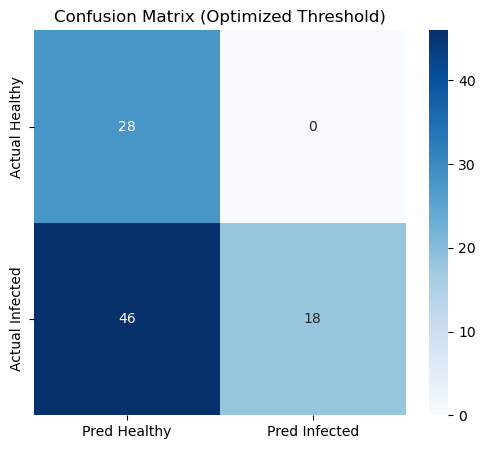

In [40]:
# We use the combined test set (Healthy + Infected)
X_input = X_test_combined 
test_preds = model_2.predict(X_input)

# Calculate Mean Squared Error (Input vs Reconstruction)
# We average over Time Steps (axis 1) and Features (axis 2)
test_mse = np.mean(np.mean(np.power(X_input - test_preds, 2), axis=1), axis=1)

print(f"MSE Calculated. Shape: {test_mse.shape}")

# Align lengths (Safety check)
min_len = min(len(test_mse), len(y_test_labels))
test_mse_fixed = test_mse[:min_len]
y_test_fixed = y_test_labels[:min_len]

# Check Average Errors
avg_healthy_err = np.mean(test_mse_fixed[y_test_fixed == 0])
avg_infected_err = np.mean(test_mse_fixed[y_test_fixed == 1])

print(f"\n--- SCORE ANALYSIS ---")
print(f"Average Error (Healthy):  {avg_healthy_err:.6f}")
print(f"Average Error (Infected): {avg_infected_err:.6f}")

# Compare
if avg_infected_err > avg_healthy_err:
    print("GOOD NEWS: The model sees a difference!")
    
    # Calculate optimal threshold (halfway point)
    new_threshold = (avg_healthy_err + avg_infected_err) / 2
    print(f"Recommended Threshold: {new_threshold:.6f}")
    
    # Generate Matrix with NEW threshold
    y_pred_new = (test_mse_fixed > new_threshold).astype(int)
    
    cm = confusion_matrix(y_test_fixed, y_pred_new)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred Healthy', 'Pred Infected'],
                yticklabels=['Actual Healthy', 'Actual Infected'])
    plt.title('Confusion Matrix (Optimized Threshold)')
    plt.show()
    
else:
    print("BAD NEWS: The model cannot distinguish Healthy from Infected.")
    print("The errors are too similar. We may need to retrain or change features.")

--- OPTIMIZATION RESULTS ---
Best Accuracy Found: 82.61%
Best Threshold:      0.149434


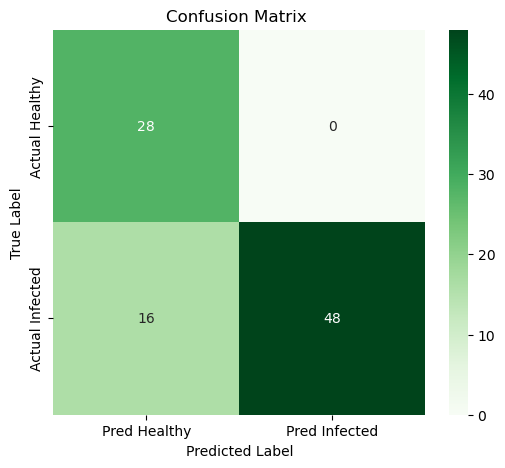

In [42]:
from sklearn.metrics import f1_score, accuracy_score

# Same as above but now we loop through multiple thresholds to find the BEST one

# 1. Define a range of possible thresholds
# From the lowest error seen to the highest error seen
thresholds = np.linspace(test_mse_fixed.min(), test_mse_fixed.max(), 100)

best_acc = 0
best_thresh = 0
best_cm = None

# 2. Loop through them
for t in thresholds:
    # Predict using this temporary threshold
    y_pred_temp = (test_mse_fixed > t).astype(int)
    
    # Calculate score (Accuracy is good, F1 is better for imbalanced data)
    acc = accuracy_score(y_test_fixed, y_pred_temp)
    
    # Save the best one
    if acc > best_acc:
        best_acc = acc
        best_thresh = t
        best_cm = confusion_matrix(y_test_fixed, y_pred_temp)

# 3. Print Results
print(f"--- OPTIMIZATION RESULTS ---")
print(f"Best Accuracy Found: {best_acc*100:.2f}%")
print(f"Best Threshold:      {best_thresh:.6f}")

# 4. Plot the BEST Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pred Healthy', 'Pred Infected'],
            yticklabels=['Actual Healthy', 'Actual Infected'])
plt.title(f'Confusion Matrix ')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Here we can see a lot more anomalies than when we tried fit the own labeled data into the model, the reasons for this and a comparison can be seen below in the disccussion.

### ROC and Precision Recall curves

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Calculate ROC Metrics
fpr, tpr, thresholds_roc = roc_curve(y_test_fixed, test_mse_fixed)
roc_auc = auc(fpr, tpr)

# 2. Calculate Precision-Recall Metrics
precision, recall, thresholds_pr = precision_recall_curve(y_test_fixed, test_mse_fixed)
avg_precision = average_precision_score(y_test_fixed, test_mse_fixed)

# 3. PLOT
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT A: ROC CURVE ---
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate (False Alarms)')
ax[0].set_ylabel('True Positive Rate (Sensitivity)')
ax[0].set_title('Receiver Operating Characteristic (ROC)')
ax[0].legend(loc="lower right")
ax[0].grid(True, alpha=0.3)

# --- PLOT B: PRECISION-RECALL CURVE ---
ax[1].plot(recall, precision, color='green', lw=2, label=f'PR curve (Avg Prec = {avg_precision:.2f})')
ax[1].set_xlabel('Recall (How many infected did we find?)')
ax[1].set_ylabel('Precision (Are the ones we found actually infected?)')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")
ax[1].grid(True, alpha=0.3)

plt.show()

print(f"ROC AUC Score:       {roc_auc:.4f} (1.0 is perfect, 0.5 is random)")
print(f"Average Precision:   {avg_precision:.4f} (1.0 is perfect)")

## 4.3 Comparison between both models and discussion

In [ ]:
# Compute reconstruction error for both models
recon1 = model.predict(X_test)
recon2 = model_2.predict(X_test_2)

mse1 = np.mean(np.power(X_test - recon1, 2), axis=(1,2))
mse2 = np.mean(np.power(X_test_2 - recon2, 2), axis=(1,2))

# Plot histograms
plt.figure(figsize=(10,5))
plt.hist(mse1, bins=50, alpha=0.6, label='Dataframe 1 (Own labeled)')
plt.hist(mse2, bins=50, alpha=0.6, label='Dataframe 2 (Already labeled)')
plt.axvline(np.percentile(mse1,95), color='blue', linestyle='--')
plt.axvline(np.percentile(mse2,95), color='orange', linestyle='--')
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Frequency")
plt.title("Comparison of Reconstruction Error Distributions")
plt.ylim(0, 500)
plt.legend()
plt.show()

As we can see here the reconstruction error in the own labeled data is nearly 3000 meanwhile in the already labeled data is near 0, we fit the same model, but have completely different results, why is that?

- Different parameters:
    it's true that both dataset were *almost* identical, but in the already labeled data we dropped the ID and the Day, things that we keeped in the own labeled data, also the already labeled have columns like weeks.
- Larger dataset: 
    The already labeled dataset is much bigger, with many more inputs to analyze, also it contains informations of 2 hives, not only one.
- Bad filtering: 
    It can be that the filtering we did was not exhaustive or good enough. 

So, the model worked?
Well its difficult to say if one of the models worked, we don't really know how an anomaly looks like, therefore we can't say, hey this anomaly was detected correctly, we need to discuss this things with the PhD in order to know if what we did was right. 

Future approaches
Things can always we better, in this case, without any feedback yet we can think on 3 things to do to improve the model.
1.  More exhaustive filtering

        As we was saying filtering might have been good enough, we can improve that
2. Have a Y (target)

        how an anomaly flight looks like will be so helpful so that we can have a supervised problem and therefore easy to compare results. 
3. Try another model

        We can try another models and see if there are better options out there that can do the work.

# 5. Research papers and Thanks
I want to thank PhD Ulises Olivares for giving me the opportunity of being part of this project. 

Below you can find the different papers he have done about this topic if you want to read more about. 

https://doi.org/10.21203/rs.3.rs-6825046/v1

https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4525546

## Useful links:
[Introduction to LSTM autoencoders](https://machinelearningmastery.com/lstm-autoencoders/)

[How to build an LSTM](https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-lstm-rnn-in-tensorflow/)

[How to build Bidirectional Networks](https://www.geeksforgeeks.org/deep-learning/bidirectional-recurrent-neural-network/)